<a href="https://colab.research.google.com/github/phhien203/ML-foundations/blob/master/TSLA_Forecast_Evaluation_Hien.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Evaluate a forecast of Tesla (TSLA)'s next day closing price

Manager's question: Can we trust this forecast enough to use it?

This notebook evaluates a forecast of Tesla's next day closing price using  OCHLV price from 2016-01-01 to 2026-10-09.

Before examining the results, the following criteria must meet, then it is recommended to manager.

- Mean MAE : naive < 0.98
- Model can beat the naive baseline in at least 4 of 6 folds
- Mean directional accuracy is not lower than the always-up base rate

The naive baseline is the price of tomorrow equals to the price of today.
Two models will be used to evaluate against the naive baseline: Ridge and XGBoost.

In [3]:
%pip install yfinance pandas numpy matplotlib scikit-learn xgboost

In [4]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error

from sklearn.pipeline import make_pipeline

# Configure Jupyter to render high-resolution figures for Retina/HD displays
%config InlineBackend.figure_format = 'retina'

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
pd.set_option('display.float_format', lambda x: '%.4f' % x)

In [5]:
START_DATE = '2016-01-01'
END_DATE = '2026-10-09'
TICKER = 'TSLA'

SEED = 42
HORIZON = 1
N_SPLITS = 6
TEST_SIZE = 250
GAP = HORIZON


In [6]:
raw = yf.download(
    TICKER,
    start=START_DATE,
    end=END_DATE,
    auto_adjust=True,
    progress=False
)

if isinstance(raw.columns, pd.MultiIndex):
  raw.columns = raw.columns.get_level_values(0)

raw = raw.sort_index()

print('First date:', raw.index.min())
print('Last date:', raw.index.max())
print('Number of rows:', len(raw))

print(raw.isna().sum())

print(raw.shape)


First date: 2016-01-04 00:00:00
Last date: 2026-10-08 00:00:00
Number of rows: 2707
Price
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64
(2707, 5)


In [7]:
df = raw.copy()

df['log_return'] = np.log(df['Close'] / df['Close'].shift(1))

df['target'] = df['log_return'].shift(-1)

df['return_today'] = df['log_return']

df.head()

Price,Close,High,Low,Open,Volume,log_return,target,return_today
Date,,,,,,,,
2016-01-04,14.8940,15.4253,14.6000,15.3813,102406500,NaN,0.0001,NaN
2016-01-05,14.8953,15.1260,14.6667,15.0907,47802000,0.0001,-0.0198,0.0001
2016-01-06,14.6027,14.6700,14.3987,14.6667,56686500,-0.0198,-0.0156,-0.0198
2016-01-07,14.3767,14.5627,14.2447,14.2793,53314500,-0.0156,-0.0218,-0.0156
2016-01-08,14.0667,14.6960,14.0513,14.5240,54421500,-0.0218,-0.0150,-0.0218


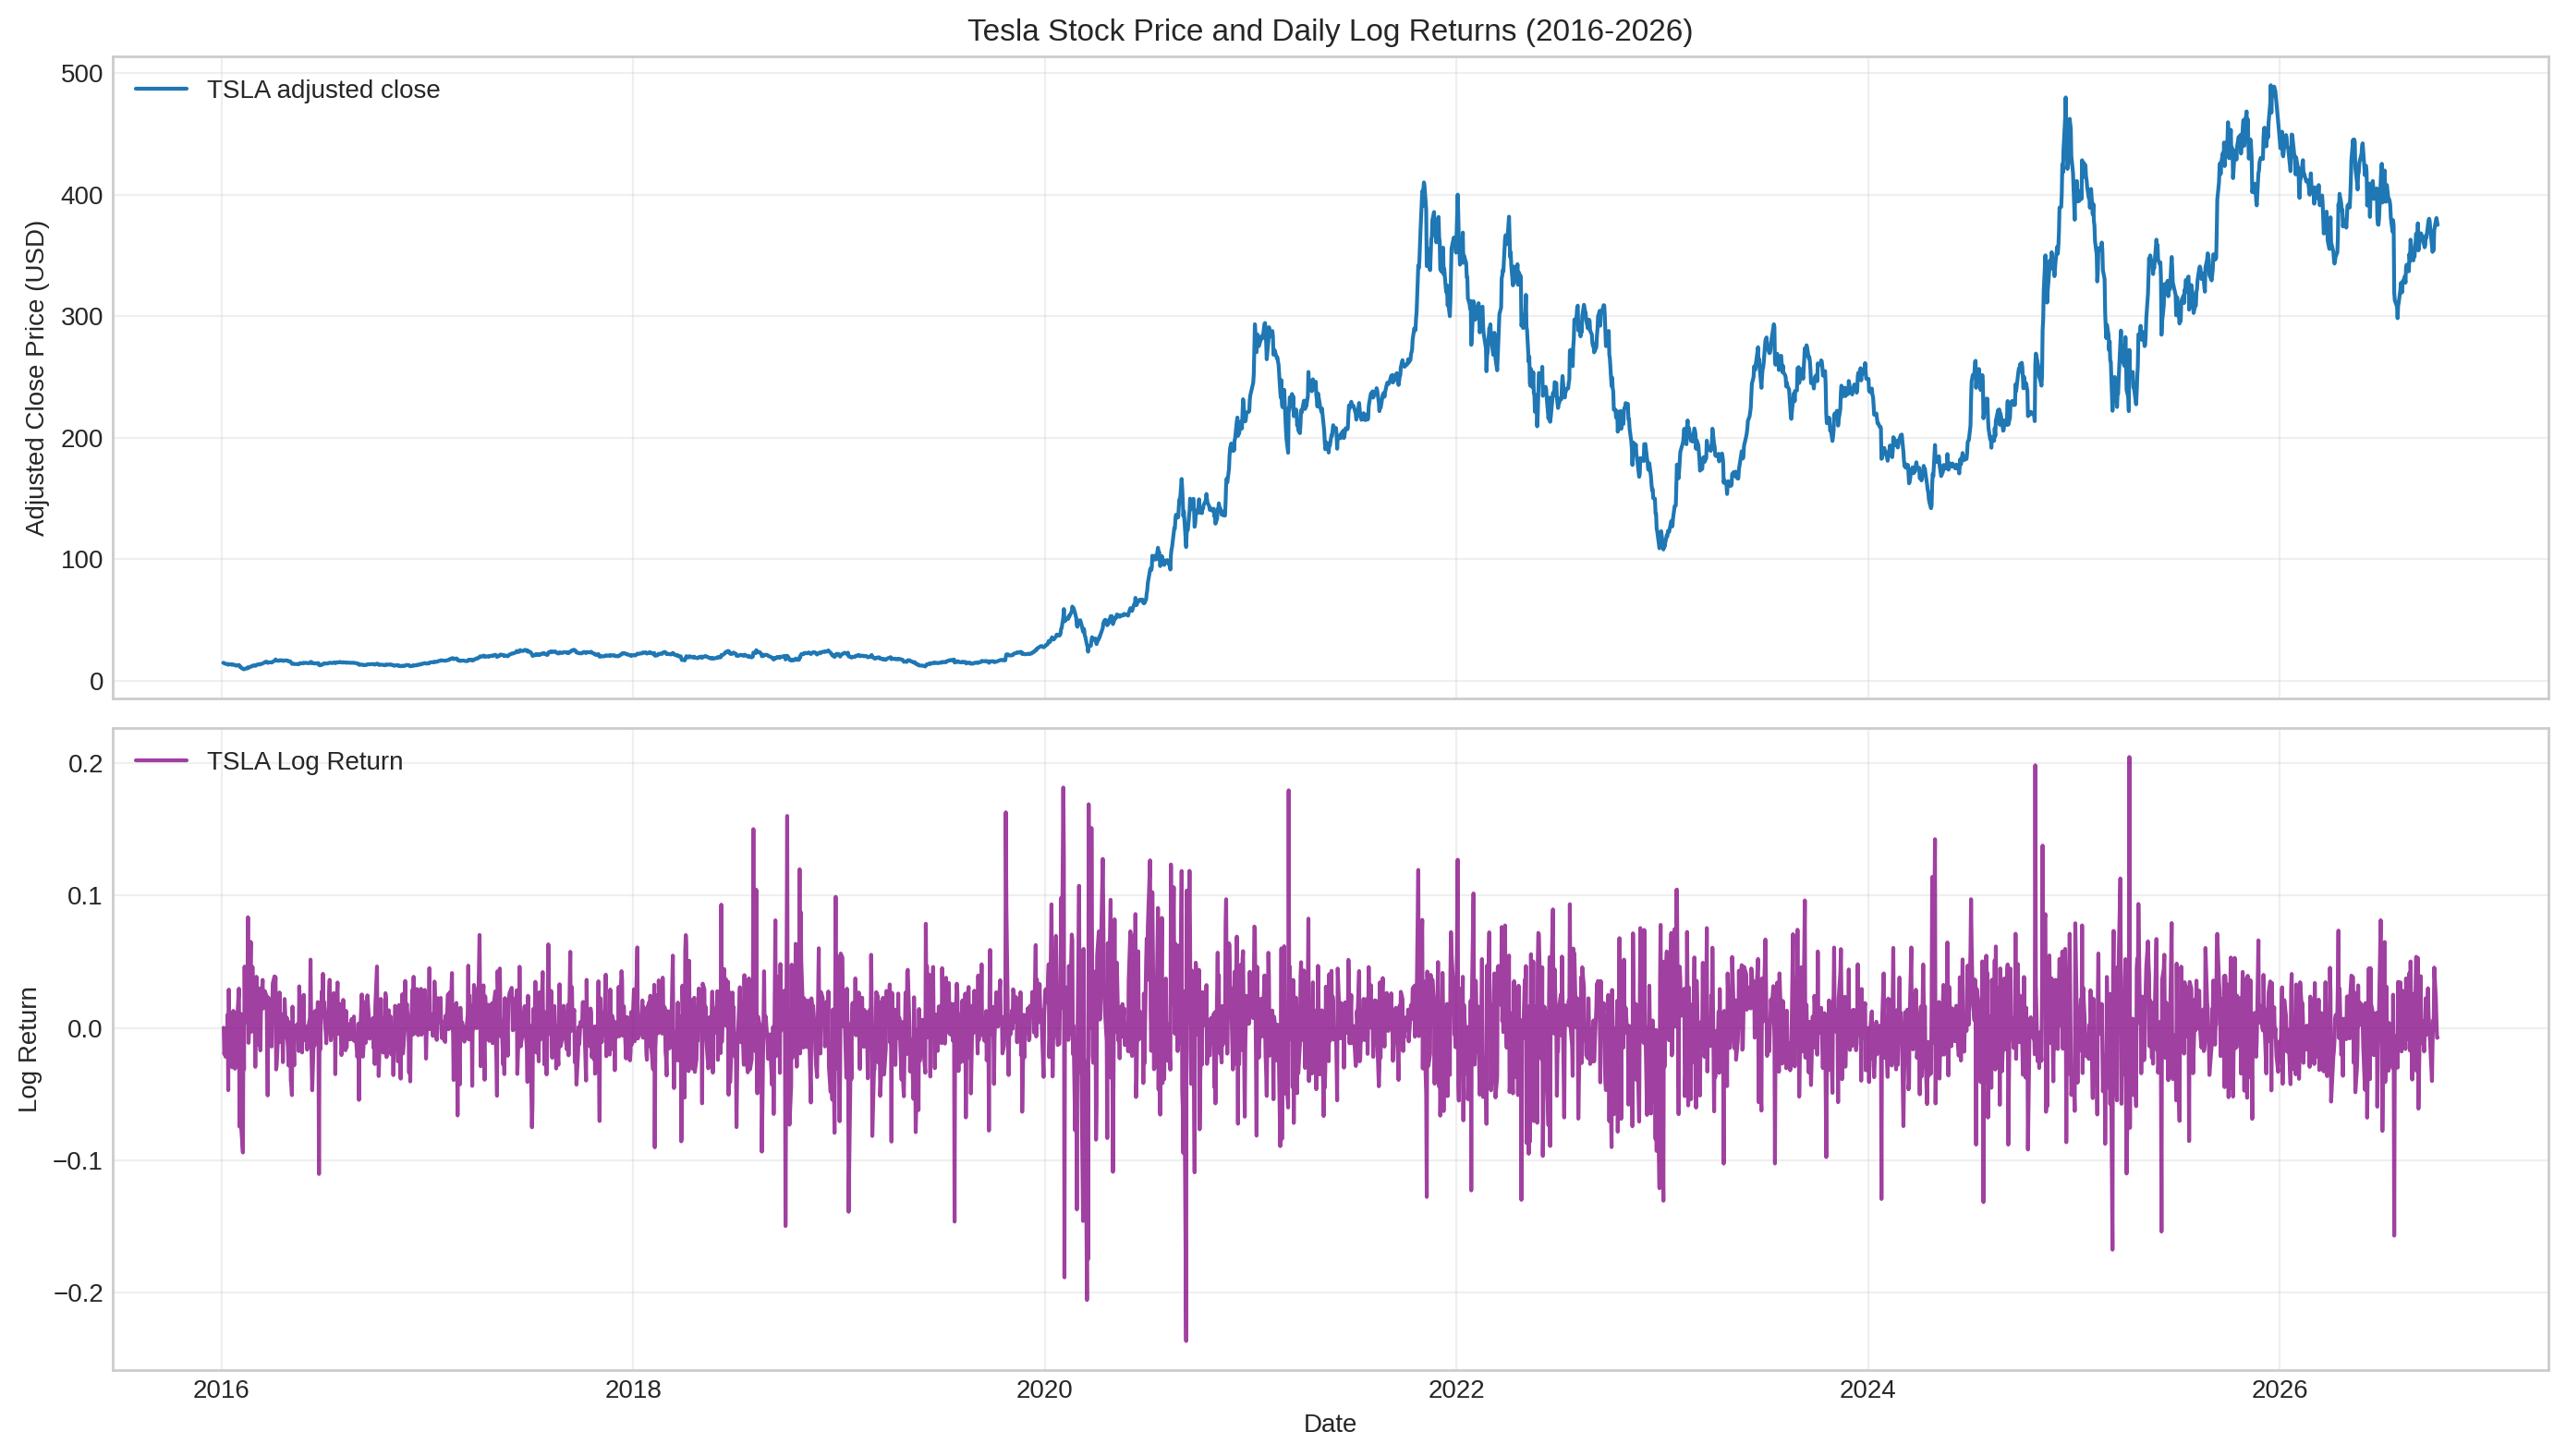

In [8]:
fig, (ax1, ax2) = plt.subplots(
    2,
    1,
    figsize=(14, 8),
    sharex=True,
    gridspec_kw={'height_ratios': [1, 1]}
)

# Top Plot: Close Price
ax1.plot(
    df.index,
    df['Close'],
    label='TSLA adjusted close',
    color='tab:blue'
)
ax1.set_title('Tesla Stock Price and Daily Log Returns (2016-2026)')
ax1.set_ylabel('Adjusted Close Price (USD)')
ax1.legend(loc='upper left')
ax1.grid(alpha=0.3)

# Bottom Plot: Log Returns
ax2.plot(
    df.index,
    df['log_return'],
    label='TSLA Log Return',
    color='purple',
    alpha=0.75
)
ax2.set_xlabel('Date')
ax2.set_ylabel('Log Return')
ax2.legend(loc='upper left')
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Features Engineering

In [9]:
# lags
df['lag_1'] = df['log_return'].shift(1)
df['lag_2'] = df['log_return'].shift(2)
df['lag_3'] = df['log_return'].shift(3)
df['lag_5'] = df['log_return'].shift(5)
df['lag_10'] = df['log_return'].shift(10)
df['lag_20'] = df['log_return'].shift(20)

# volatility
df['volatility_5'] = df['log_return'].rolling(window=5).std()
df['volatility_10'] = df['log_return'].rolling(window=10).std()
df['volatility_20'] = df['log_return'].rolling(window=20).std()

# momentum
df['momentum_5'] = df['log_return'].rolling(window=5).sum()
df['momentum_10'] = df['log_return'].rolling(window=10).sum()
df['momentum_20'] = df['log_return'].rolling(window=20).sum()

df['ma_20'] = df['Close'].rolling(window=20).mean()
df['distance_ma20'] = df['Close'] / df['ma_20'] - 1

df['day_of_week'] = df.index.dayofweek


df.head(3)

Price,Close,High,Low,Open,Volume,log_return,target,return_today,lag_1,lag_2,...,lag_20,volatility_5,volatility_10,volatility_20,momentum_5,momentum_10,momentum_20,ma_20,distance_ma20,day_of_week
Date,,,,,,,,,,,,,,,,,,,,,
2016-01-04,14.8940,15.4253,14.6000,15.3813,102406500,NaN,0.0001,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
2016-01-05,14.8953,15.1260,14.6667,15.0907,47802000,0.0001,-0.0198,0.0001,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
2016-01-06,14.6027,14.6700,14.3987,14.6667,56686500,-0.0198,-0.0156,-0.0198,0.0001,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2


In [10]:
feature_columns = [
    'return_today',
    'lag_1',
    'lag_2',
    'lag_3',
    'lag_5',
    'lag_10',
    'lag_20',
    'volatility_5',
    'volatility_10',
    'volatility_20',
    'momentum_5',
    'momentum_10',
    'momentum_20',
    'distance_ma20',
    'day_of_week'
]

data = df.dropna(subset=feature_columns + ['target']).copy()

X = data[feature_columns]
y = data['target']

print('Features:', X.shape)
print('Target:', y.shape)


Features: (2685, 15)
Target: (2685,)


## Evaluation

In [11]:
tscv = TimeSeriesSplit(
    n_splits=N_SPLITS,
    test_size=TEST_SIZE,
    gap=GAP
)

In [12]:
results = []
predictions = []
fold_periods = []

for fold, (train_idx, test_idx) in enumerate(tscv.split(X), start=1):
  assert train_idx.max() + GAP < test_idx.min()

  # ------------------------------
  # 1. Split the train, test
  # ------------------------------
  X_train = X.iloc[train_idx]
  X_test = X.iloc[test_idx]

  y_train = y.iloc[train_idx]
  y_test = y.iloc[test_idx]

  fold_periods.append({
      'fold': fold,
      'train_start': X_train.index.min(),
      'train_end': X_train.index.max(),
      'test_start': X_test.index.min(),
      'test_end': X_test.index.max(),
      'n_train': len(train_idx),
      'n_test': len(test_idx)
  })

  # ------------------------------
  # 2. Create models
  # ------------------------------
  models = {
      'Ridge': make_pipeline(
          StandardScaler(),
          Ridge(alpha=10.0)
      ),
      'XGBoost': XGBRegressor(
          n_estimators=200,
          learning_rate=0.02,
          max_depth=3,
          min_child_weight=20,
          subsample=0.8,
          colsample_bytree=0.8,
          reg_lambda=5.0,
          # early_stopping_rounds=100,
          random_state=SEED
      )
  }

  # ------------------------------
  # 3. Train and predict
  # ------------------------------
  naive_return_pred = np.zeros(len(y_test))

  return_predictions = {
      'Naive': naive_return_pred
  }

  for name, model in models.items():
    model.fit(
        X_train,
        y_train
    )
    return_pred = model.predict(X_test)
    return_predictions[name] = return_pred


  # ------------------------------
  # 4. Convert return to price
  # ------------------------------
  current_price = data.loc[X_test.index, 'Close'].to_numpy()

  actual_return = y_test.to_numpy()

  actual_price = current_price * np.exp(actual_return)

  naive_price = current_price * np.exp(naive_return_pred)

  naive_mea = mean_absolute_error(actual_price, naive_price)

  # ------------------------------
  # 5. Evaluate every model
  # ------------------------------
  for name, return_pred in return_predictions.items():
    predicted_price = current_price * np.exp(return_pred)

    mae = mean_absolute_error(actual_price, predicted_price)

    rmse = np.sqrt(
        mean_squared_error(actual_price, predicted_price)
    )

    mape = np.mean(np.abs((actual_price - predicted_price) / actual_price)) * 100

    mae_ratio = mae / naive_mea

    results.append({
        'fold': fold,
        'model': name,
        'MAE_USD': mae,
        'RMSE_USD': rmse,
        'MAPE_pct': mape,
        'MAE_div_naive': mae_ratio
    })

    # Daily predictions for figures
    fold_predictions = pd.DataFrame({
        'fold': fold,
        'model': name,
        'current_price': current_price,
        'actual_price': actual_price,
        'predicted_price': predicted_price,
        'actual_return': actual_return,
        'predicted_return': return_pred
    }, index=X_test.index)

    predictions.append(fold_predictions)

  print(f'Fold {fold} completed')


Fold 1 completed
Fold 2 completed
Fold 3 completed
Fold 4 completed
Fold 5 completed
Fold 6 completed


In [13]:
results_df = pd.DataFrame(results)

display(results_df.sort_values(['fold', 'model']).round(4))

,fold,model,MAE_USD,RMSE_USD,MAPE_pct,MAE_div_naive
0,1,Naive,5.3224,7.3284,2.4126,1.0000
1,1,Ridge,5.3539,7.3542,2.4299,1.0059
2,1,XGBoost,5.4062,7.5075,2.4503,1.0157
3,2,Naive,9.4013,12.5076,3.1634,1.0000
4,2,Ridge,9.4552,12.6500,3.1921,1.0057
5,2,XGBoost,9.4951,12.5976,3.1994,1.0100
6,3,Naive,5.5845,7.3651,2.8232,1.0000
7,3,Ridge,5.5442,7.3531,2.8088,0.9928
8,3,XGBoost,5.5460,7.3537,2.8112,0.9931
9,4,Naive,5.3010,7.2075,2.5548,1.0000


In [14]:
summary_df = results_df.groupby('model').agg(
    MAE_mean=('MAE_USD', 'mean'),
    MAE_std=('MAE_USD', 'std'),

    RMSE_mean=('RMSE_USD', 'mean'),
    RMSE_std=('RMSE_USD', 'std'),

    MAPE_mean=('MAPE_pct', 'mean'),
    MAPE_std=('MAPE_pct', 'std'),

    Ratio_mean=('MAE_div_naive', 'mean'),
    Ratio_std=('MAE_div_naive', 'std')
)

display(summary_df.round(4))

,MAE_mean,MAE_std,RMSE_mean,RMSE_std,MAPE_mean,MAPE_std,Ratio_mean,Ratio_std
model,,,,,,,,
Naive,7.4485,2.2936,9.9335,2.9738,2.7210,0.4015,1.0000,0.0000
Ridge,7.4758,2.3240,9.9815,3.0087,2.7349,0.4113,1.0030,0.0059
XGBoost,7.4957,2.3050,9.9921,2.9642,2.7430,0.3982,1.0064,0.0079


In [15]:
metrics = [
    "MAE_USD",
    "RMSE_USD",
    "MAPE_pct",
    "MAE_div_naive"
]

summary_report = pd.DataFrame()

for metric in metrics:

    grouped = results_df.groupby("model")[metric]

    mean = grouped.mean()
    std = grouped.std()

    summary_report[metric] = [
        f"{mean.loc[m]:.4f} ± {std.loc[m]:.4f}"
        for m in mean.index
    ]

display(summary_report)

,MAE_USD,RMSE_USD,MAPE_pct,MAE_div_naive
0,7.4485 ± 2.2936,9.9335 ± 2.9738,2.7210 ± 0.4015,1.0000 ± 0.0000
1,7.4758 ± 2.3240,9.9815 ± 3.0087,2.7349 ± 0.4113,1.0030 ± 0.0059
2,7.4957 ± 2.3050,9.9921 ± 2.9642,2.7430 ± 0.3982,1.0064 ± 0.0079


In [16]:
ratio_table = results_df.pivot(
    index="fold",
    columns="model",
    values="MAE_div_naive"
)

display(ratio_table.round(4))

print(
    "Ridge wins:",
    (ratio_table["Ridge"] < 1).sum(),
    "out of 6 folds"
)

print(
    "XGBoost wins:",
    (ratio_table["XGBoost"] < 1).sum(),
    "out of 6 folds"
)

model,Naive,Ridge,XGBoost
fold,,,
1,1.0000,1.0059,1.0157
2,1.0000,1.0057,1.0100
3,1.0000,0.9928,0.9931
4,1.0000,1.0041,1.0097
5,1.0000,1.0096,1.0022
6,1.0000,0.9998,1.0080


Ridge wins: 2 out of 6 folds
XGBoost wins: 1 out of 6 folds


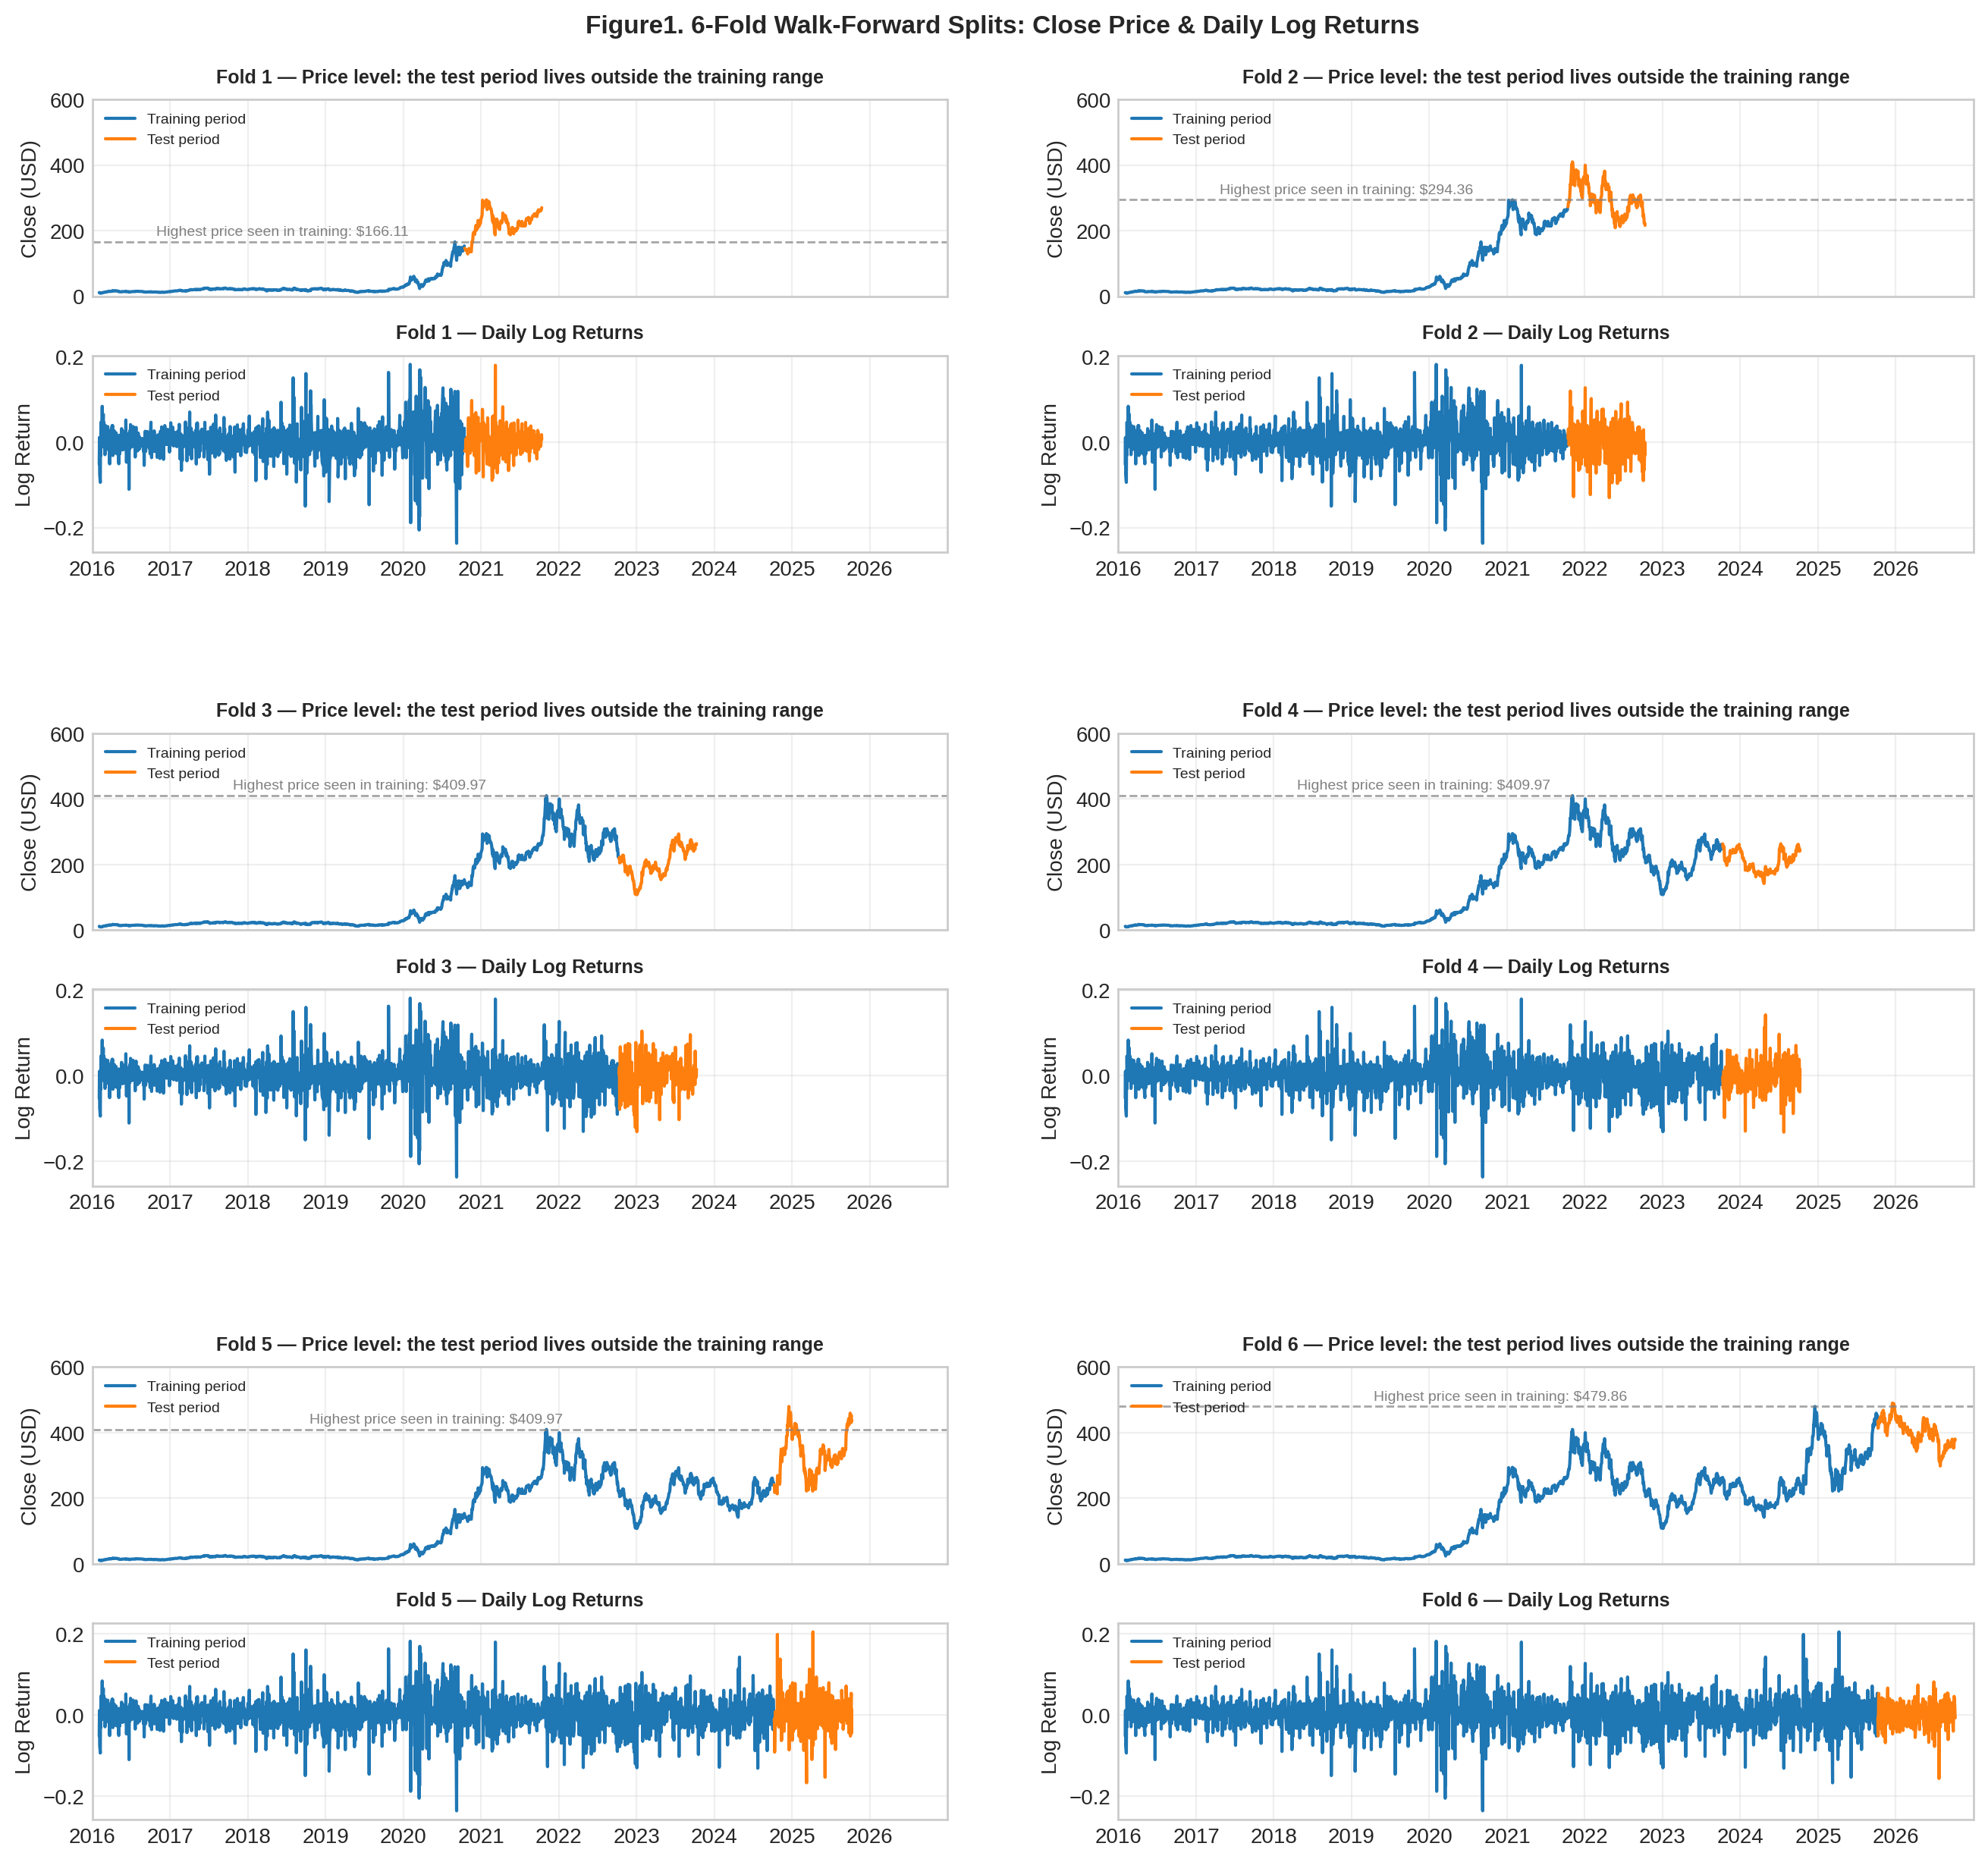

In [61]:
import matplotlib.gridspec as gridspec
import datetime

fig = plt.figure(figsize=(16, 14))

outer_gs = gridspec.GridSpec(
    3,
    2,
    figure=fig,
    hspace=0.40,
    wspace=0.20
)

for i, row in folds_df.iterrows():
    fold_num = int(row['fold'])

    # Slice dataset for Train & Test
    train_mask = (df.index >= row['train_start']) & (df.index <= row['train_end'])
    test_mask = (df.index >= row['test_start']) & (df.index <= row['test_end'])

    train_df = df.loc[train_mask]
    test_df = df.loc[test_mask]

    # Calculate the highest training close price
    max_train_close = train_df['Close'].max()

    # Determine 3x2 grid cell position
    outer_row = i // 2
    outer_col = i % 2

    inner_gs = gridspec.GridSpecFromSubplotSpec(
        2, 1,
        subplot_spec=outer_gs[outer_row, outer_col],
        hspace=0.30
    )

    ax_close = fig.add_subplot(inner_gs[0])
    ax_return = fig.add_subplot(inner_gs[1], sharex=ax_close)

    ax_close.plot(
        train_df.index,
        train_df['Close'],
        label='Training period',
        color='tab:blue'
    )
    ax_close.plot(
        test_df.index,
        test_df['Close'],
        label='Test period',
        color='tab:orange'
    )

    ax_close.axhline(
        max_train_close,
        color='gray',
        linestyle='--',
        alpha=0.7,
        linewidth=1.0
    )

    label_x = train_df.index[int(len(train_df) * 0.5)]
    ax_close.text(
        label_x,
        max_train_close + 10,
        f'Highest price seen in training: ${max_train_close:.2f}',
        color='gray',
        fontsize=7,
        ha='center',
        va='bottom'
    )

    ax_close.set_ylim(0, 600)

    ax_close.set_xlim(datetime.date(2016, 1, 1), datetime.date(2026, 12, 31))

    ax_close.set_title(
        f"Fold {fold_num} — Price level: the test period lives outside the training range",
        fontsize=9,
        fontweight='bold',
        pad=8
    )
    ax_close.set_ylabel("Close (USD)")
    ax_close.legend(loc='upper left', fontsize=7)
    ax_close.grid(alpha=0.3)

    ax_return.plot(
        train_df.index,
        train_df['log_return'],
        label='Training period',
        color='tab:blue',
        alpha=1.0
    )
    ax_return.plot(
        test_df.index,
        test_df['log_return'],
        label='Test period',
        color='tab:orange',
        alpha=1.0
    )
    ax_return.set_title(
        f"Fold {fold_num} — Daily Log Returns",
        fontsize=9,
        fontweight='bold',
        pad=8
    )
    ax_return.set_ylabel("Log Return")
    ax_return.legend(loc='upper left', fontsize=7)
    ax_return.grid(alpha=0.3)

    plt.setp(ax_close.get_xticklabels(), visible=False)

fig.subplots_adjust(top=0.92)
plt.suptitle(
    "Figure1. 6-Fold Walk-Forward Splits: Close Price & Daily Log Returns",
    fontsize=12,
    fontweight='bold',
    y=0.96
)
plt.savefig("figure1_folds_high.png", dpi=200, bbox_inches='tight')
plt.show()

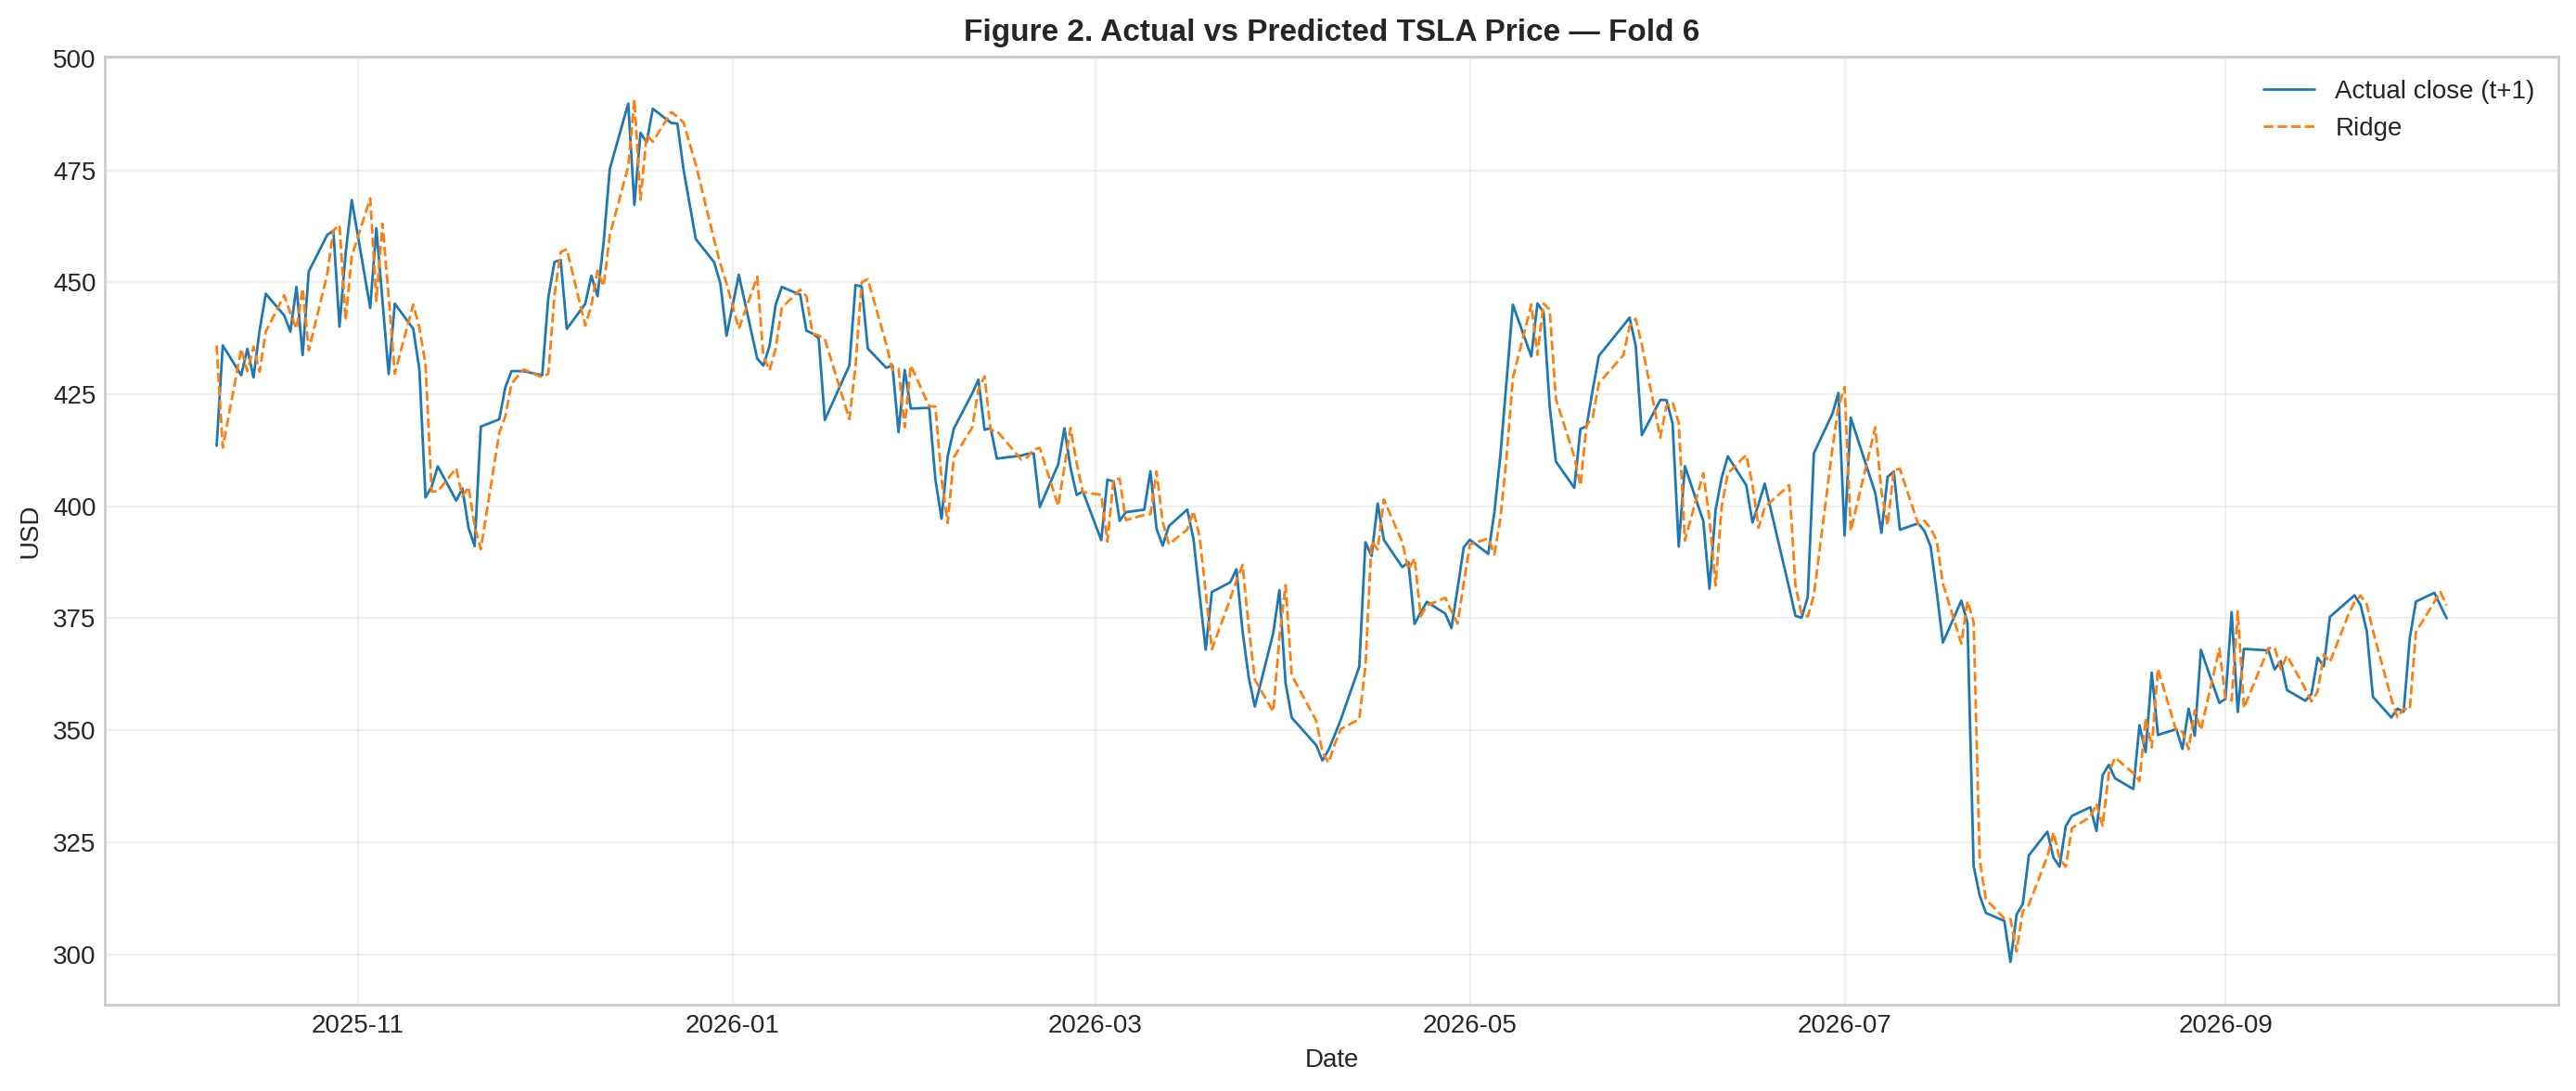

In [51]:
predictions_df = pd.concat(
    predictions
).sort_index()

fold_6 = predictions_df[
    predictions_df["fold"] == 6
]

actual = (
    fold_6[fold_6["model"] == "Naive"]
    ["actual_price"]
)

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(
    actual.index,
    actual.values,
    label="Actual close (t+1)",
    linewidth=1
)

# for model_name in ["Naive", "Ridge", "XGBoost"]:
for model_name in ["Ridge"]:

    model_data = fold_6[
        fold_6["model"] == model_name
    ]

    ax.plot(
        model_data.index,
        model_data["predicted_price"],
        label=model_name,
        alpha=1.0,
        linestyle='--',
        linewidth=1
    )

ax.set_title(
    "Figure 2. Actual vs Predicted TSLA Price — Fold 6",
    fontweight='bold',
    fontsize=12
)

ax.set_xlabel("Date")
ax.set_ylabel("USD")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("figure2_forecast_vs_actual.png", dpi=200)
plt.show()

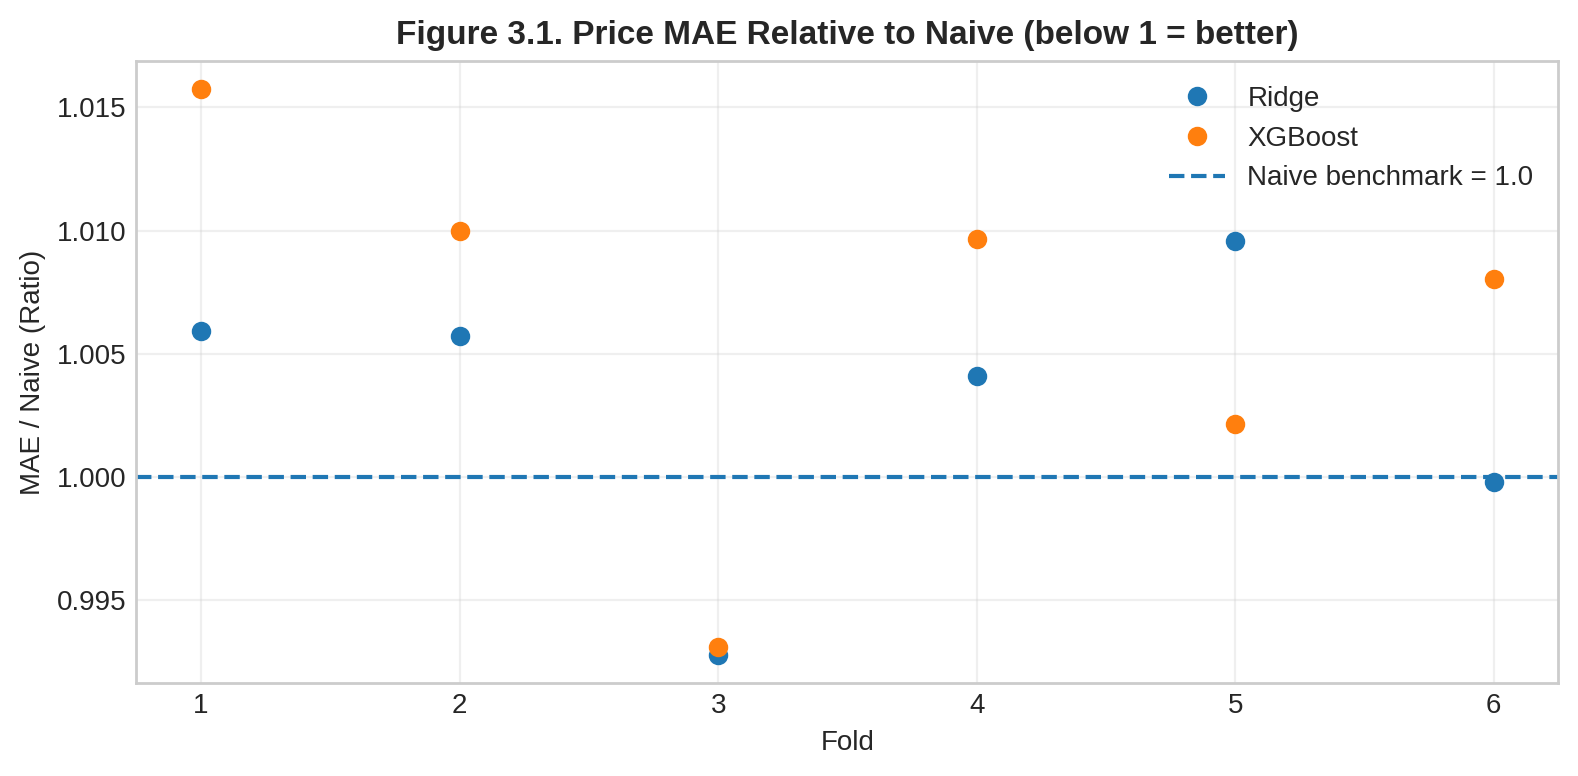

In [60]:
ratio_table = results_df.pivot(
    index="fold",
    columns="model",
    values="MAE_div_naive"
)

fig, ax = plt.subplots(figsize=(8, 4))

for model_name in ["Ridge", "XGBoost"]:
    ax.plot(
        ratio_table.index,
        ratio_table[model_name],
        marker="o",
        linestyle="None",
        label=model_name
    )

ax.axhline(
    y=1,
    linestyle="--",
    label="Naive benchmark = 1.0"
)

ax.set_title(
    "Figure 3.1. Price MAE Relative to Naive (below 1 = better)",
    fontweight='bold',
    fontsize=12
)

ax.set_xlabel("Fold")
ax.set_ylabel("MAE / Naive (Ratio)")
ax.set_xticks(range(1, 7))
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("figure31_mae_ratio_per_fold.png", dpi=200)
plt.show()

In [22]:
direction_results = []

for fold in range(1, 7):

    fold_data = predictions_df[
        predictions_df["fold"] == fold
    ]

    actual_returns = (
        fold_data[fold_data["model"] == "Naive"]
        ["actual_return"]
        .to_numpy()
    )

    # Always-up baseline
    always_up_accuracy = (
        actual_returns > 0
    ).mean()

    for model_name in ["Ridge", "XGBoost"]:

        model_data = fold_data[
            fold_data["model"] == model_name
        ]

        predicted_returns = (
            model_data["predicted_return"]
            .to_numpy()
        )

        directional_accuracy = (
            (predicted_returns > 0)
            == (actual_returns > 0)
        ).mean()

        direction_results.append({
            "fold": fold,
            "model": model_name,
            "directional_accuracy": directional_accuracy,
            "always_up_accuracy": always_up_accuracy
        })

direction_df = pd.DataFrame(direction_results)

display(direction_df.round(4))

,fold,model,directional_accuracy,always_up_accuracy
0,1,Ridge,0.5160,0.5440
1,1,XGBoost,0.5520,0.5440
2,2,Ridge,0.5200,0.5120
3,2,XGBoost,0.5280,0.5120
4,3,Ridge,0.5200,0.5200
5,3,XGBoost,0.5200,0.5200
6,4,Ridge,0.5040,0.5200
7,4,XGBoost,0.4880,0.5200
8,5,Ridge,0.4880,0.5000
9,5,XGBoost,0.5440,0.5000


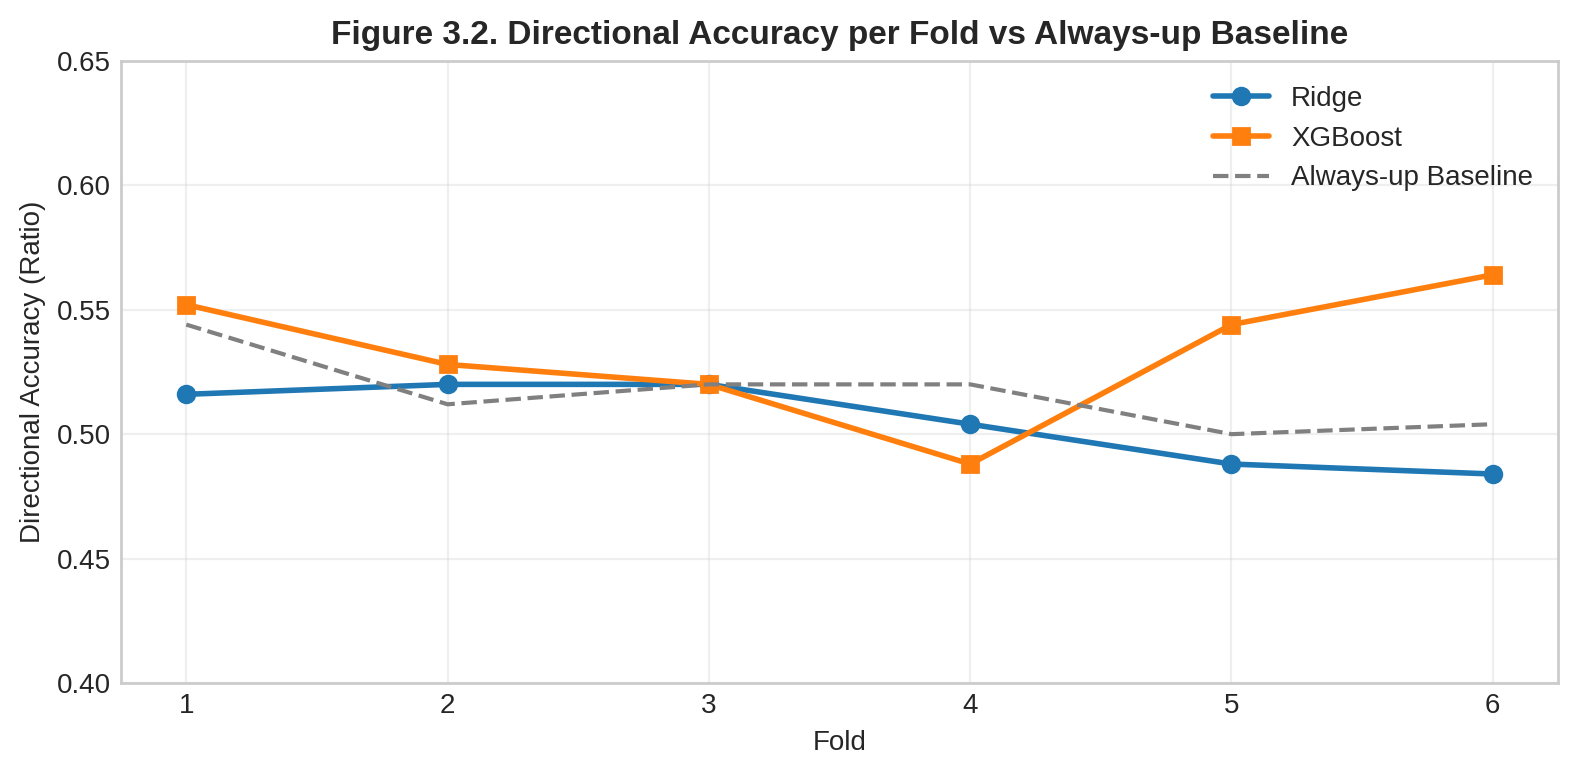

In [59]:
import matplotlib.pyplot as plt

# Pivot the direction dataframe for plotting
dir_pivot = direction_df.pivot(index='fold', columns='model', values='directional_accuracy')
always_up = direction_df.groupby('fold')['always_up_accuracy'].first()

fig, ax = plt.subplots(figsize=(8, 4))

# Plot directional accuracies
ax.plot(dir_pivot.index, dir_pivot['Ridge'], marker='o', label='Ridge', linewidth=2)
ax.plot(dir_pivot.index, dir_pivot['XGBoost'], marker='s', label='XGBoost', linewidth=2)

# Plot Always-up baseline
ax.plot(always_up.index, always_up, linestyle='--', color='gray', label='Always-up Baseline', linewidth=1.5)

ax.set_title("Figure 3.2. Directional Accuracy per Fold vs Always-up Baseline", fontweight='bold', fontsize=12)
ax.set_xlabel("Fold")
ax.set_ylabel("Directional Accuracy (Ratio)")
ax.set_xticks(range(1, 7))
ax.set_ylim(0.40, 0.65)
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("figure32_directional_accuracy.png", dpi=200)
plt.show()

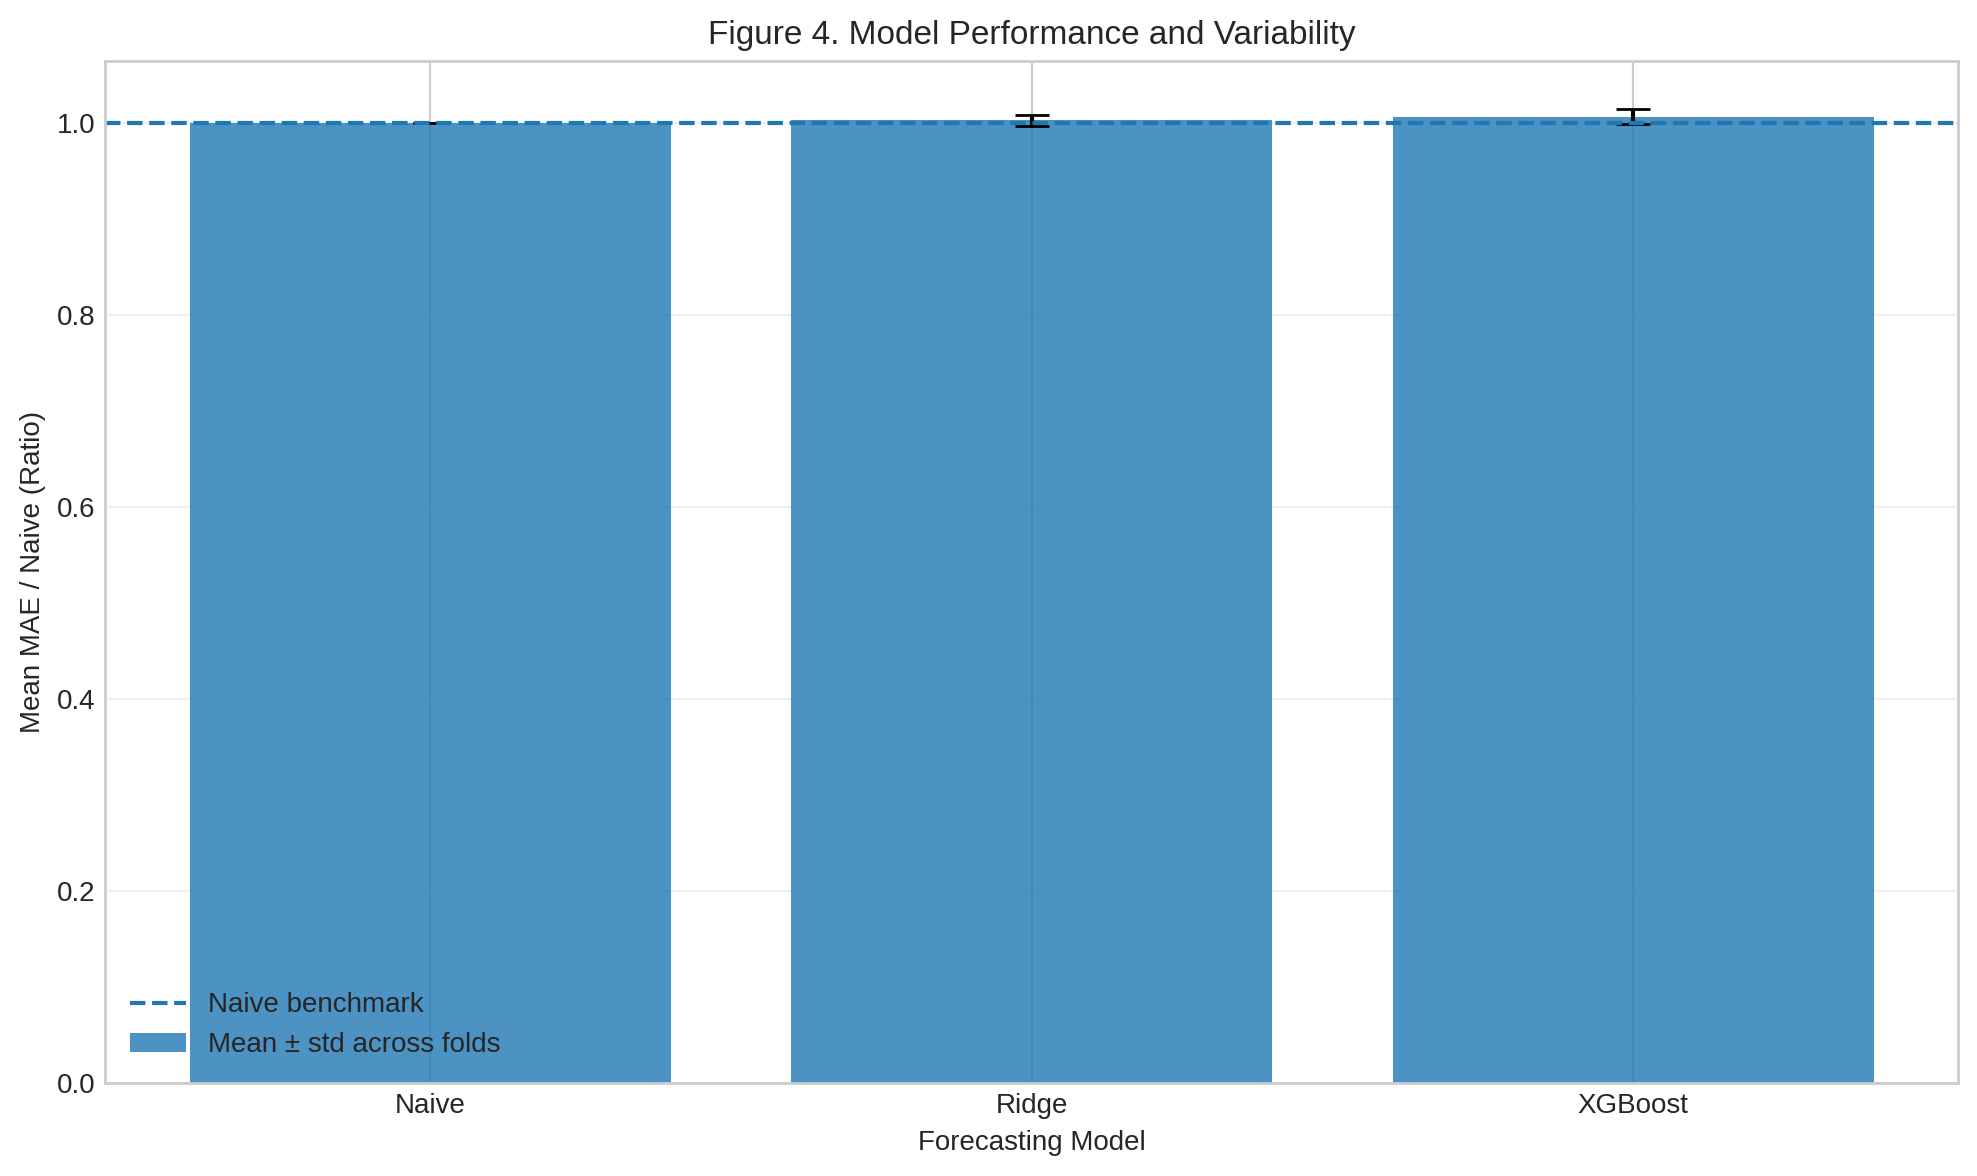

In [21]:
model_summary = (
    results_df
    .groupby("model")["MAE_div_naive"]
    .agg(["mean", "std"])
)

model_order = ["Naive", "Ridge", "XGBoost"]

model_summary = model_summary.loc[model_order]

fig, ax = plt.subplots(figsize=(10, 6))

ax.bar(
    model_summary.index,
    model_summary["mean"],
    yerr=model_summary["std"].fillna(0),
    capsize=6,
    alpha=0.8,
    label="Mean ± std across folds"
)

ax.axhline(
    1,
    linestyle="--",
    label="Naive benchmark"
)

ax.set_title(
    "Figure 4. Model Performance and Variability"
)

ax.set_xlabel("Forecasting Model")
ax.set_ylabel("Mean MAE / Naive (Ratio)")
ax.legend()
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("figure4_model_comparison.png", dpi=200)
plt.show()

Image size: (1652, 766)


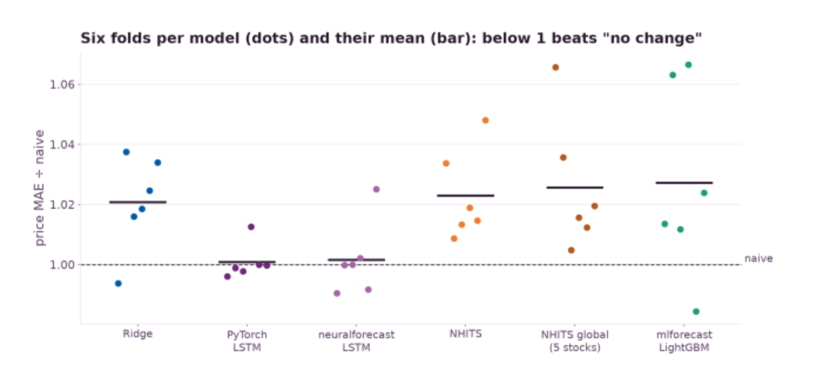

In [64]:
from PIL import Image
img = Image.open('/content/CleanShot 2026-10-09 at 20.20.17.png')
print('Image size:', img.size)
display(img.resize((826, 383)))